#### Core Loss Modeling of Magnetic Components
* Dataset source: Princeton University - MagNet Challenge, https://www.princeton.edu/~minjie/magnet.html
* This dataset is a downsampled version (one material, reduced data) for a quick illustration
* Inputs include hybrid signal-domain (B waveform) and tabular data (frequency, temperature), the output is tabular
* B waveforms are still treated as signal-domain waveforms
* Model: Modular inputs (BiLSTM to extract features from time-domain waveforms, and then use feedforward layers to aggregate the feature with the original inputs)

In [1]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Load the downscaled files
waveforms = np.loadtxt("B_waveform[T]_downscaled.csv", delimiter=",")
frequencies = np.loadtxt("Frequency[Hz]_downscaled.csv", delimiter=",")
temperatures = np.loadtxt("Temperature[C]_downscaled.csv", delimiter=",")
volumetric_losses = np.loadtxt("Volumetric_losses[Wm-3]_downscaled.csv", delimiter=",")

# Basic shape assertions and reshaping for consistency
num_waveforms, seq_len = waveforms.shape
print(f"Number of waveforms (downscaled): {num_waveforms}")
print(f"Sequence length: {seq_len}")

if frequencies.ndim == 1:
    frequencies = frequencies.reshape(-1, 1)
if temperatures.ndim == 1:
    temperatures = temperatures.reshape(-1, 1)
if volumetric_losses.ndim == 1:
    volumetric_losses = volumetric_losses.reshape(-1, 1)

numeric_features = np.hstack([frequencies, temperatures])  # shape: (num_waveforms, num_harmonics+2)
y = volumetric_losses

print(f"Downsampled waveforms shape: {waveforms.shape}")
print(f"Downsampled input features shape: {numeric_features.shape}")
print(f"Downsampled output variable y shape: {y.shape}")

Number of waveforms (downscaled): 3257
Sequence length: 1024
Downsampled waveforms shape: (3257, 1024)
Downsampled input features shape: (3257, 2)
Downsampled output variable y shape: (3257, 1)


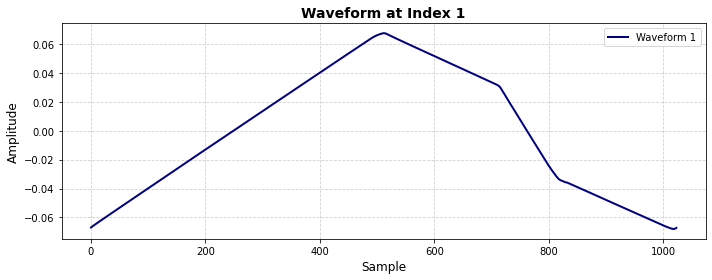

In [2]:
# Basic Data Visualization
import numpy as np
import matplotlib.pyplot as plt

def plot_waveform(index):
    """
    Plot the waveform at the specified index from the waveforms array.
    """
    if not (0 <= index < waveforms.shape[0]):
        print(f"Index {index} is out of bounds (0, {waveforms.shape[0] - 1})")
        return

    plt.figure(figsize=(10, 4))
    plt.plot(
        waveforms[index],
        color='navy',
        linewidth=2,
        label=f'Waveform {index}'
    )
    plt.title(f"Waveform at Index {index}", fontsize=14, fontweight='bold')
    plt.xlabel("Sample", fontsize=12)
    plt.ylabel("Amplitude", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper right', fontsize=10)
    plt.tight_layout()
    plt.show()

index = 1
plot_waveform(index)

#### 2 Data Partition, Preprocessing, and Define PyTorch DataLoader
---
2.1 Data Partition:
- The code for partitioning the data (train/validation/test split) is fixed and should not be modified.

**2.2 Data Preprocessing Strategies:**

    - You may apply various data preprocessing techniques (e.g., `StandardScaler`, etc.).
- For more details, refer to the [scikit-learn preprocessing documentation](https://scikit-learn.org/stable/modules/preprocessing.html).

**2.3 Define PyTorch DataLoader:**
- Batch size for the training set dataloader might affect the NN accuracy, and can be tuned.
---

In [3]:
# Data Partition
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import torch
from torch.utils.data import TensorDataset
import numpy as np

# There are two types of features:
#   - Time sequence features: X_time (e.g., waveforms: shape (N, seq_len))
#   - Numeric features:      X_num  (e.g., [frequency, temperature]: shape (N, 2))
# Output:                    y       (N, 1)

# Partition BOTH data formats into train/val/test splits with the same indices, preserving full/consistent splits.
# The y variable is already 2D shape (N, 1), as ensured in data loading.

# Use the "downsampled" data for modeling, following convention from context (`waveforms_ds`, `numeric_features_ds`, `y_ds`)
X_time = waveforms            # (N, seq_len)
X_num = numeric_features      # (N, 2)
y = y                        # (N, 1)

# Get train/val/test split indices ONCE using train_test_split on just an array of indices
num_samples = X_time.shape[0]
idx_all = np.arange(num_samples)
idx_temp, idx_test = train_test_split(idx_all, test_size=0.2, random_state=42)
idx_train, idx_val = train_test_split(idx_temp, test_size=0.25, random_state=42)  # 0.25*0.8=0.2

# Partition time sequence features
X_time_train, X_time_val, X_time_test = X_time[idx_train], X_time[idx_val], X_time[idx_test]
# Partition numeric features
X_num_train, X_num_val, X_num_test = X_num[idx_train], X_num[idx_val], X_num[idx_test]
# Partition outputs
y_train, y_val, y_test = y[idx_train], y[idx_val], y[idx_test]

# Standardize time sequence features using training set statistics
seq_scaler = StandardScaler()
X_time_train_scaled = seq_scaler.fit_transform(X_time_train)
X_time_val_scaled   = seq_scaler.transform(X_time_val)
X_time_test_scaled  = seq_scaler.transform(X_time_test)

# Standardize numeric features (e.g., frequency, temperature) using training set statistics
num_scaler = StandardScaler()
X_num_train_scaled = num_scaler.fit_transform(X_num_train)
X_num_val_scaled   = num_scaler.transform(X_num_val)
X_num_test_scaled  = num_scaler.transform(X_num_test)

# Output preprocessing: log transform, then MinMax scaling (fit only on training set)
epsilon = 1e-12  # To avoid log(0)
output_scaler = MinMaxScaler()

y_train_log = np.log(y_train + epsilon)
y_val_log   = np.log(y_val + epsilon)
y_test_log  = np.log(y_test + epsilon)

y_train_scaled = output_scaler.fit_transform(y_train_log.reshape(-1, 1))
y_val_scaled   = output_scaler.transform(y_val_log.reshape(-1, 1))
y_test_scaled  = output_scaler.transform(y_test_log.reshape(-1, 1))

# X_time_train_scaled:  (N_train, seq_len)
# X_num_train_scaled:   (N_train, 2)
# y_train_scaled:       (N_train, 1)

In [4]:
# Define PyTorch DataLoader
from torch.utils.data import DataLoader

# Reshape sequence features to (N_samples, seq_len, input_dim) for LSTM
# Assume input_dim=1 for a single feature per timestep
def reshape_time_feature(x):
    if len(x.shape) == 2:  # (N, seq_len) -> (N, seq_len, 1)
        return x[..., np.newaxis]
    return x

X_time_train_seq = reshape_time_feature(X_time_train_scaled)
X_time_val_seq   = reshape_time_feature(X_time_val_scaled)
X_time_test_seq  = reshape_time_feature(X_time_test_scaled)

# Combine both scaled feature types into TensorDatasets for PyTorch
# Each sample contains (sequence_features, numeric_features, target)
train_set = TensorDataset(
    torch.tensor(X_time_train_seq, dtype=torch.float32),  # (N_train, seq_len, input_dim)
    torch.tensor(X_num_train_scaled, dtype=torch.float32),
    torch.tensor(y_train_scaled, dtype=torch.float32)
)
val_set = TensorDataset(
    torch.tensor(X_time_val_seq, dtype=torch.float32),
    torch.tensor(X_num_val_scaled, dtype=torch.float32),
    torch.tensor(y_val_scaled, dtype=torch.float32)
)
test_set = TensorDataset(
    torch.tensor(X_time_test_seq, dtype=torch.float32),
    torch.tensor(X_num_test_scaled, dtype=torch.float32),
    torch.tensor(y_test_scaled, dtype=torch.float32)
)

batch_size = 600
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)

val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

## 3 Core Loss Modeling for Magnetic Material 3C90: Define Recurrent Neural Networks
---
**3.1 Define Recurrent Neural Network Structure:**

- Layers: BatchNorm/LayerNorm, dropout, residual, convolutional, recurrent, attention, etc.
- Activation: SiLU, GLU, Sigmoid, Tanh, etc.

**3.2 Tune Recurrent Neural Network Structure:**

    - Number of hidden layers, and number of hidden units inside each layer can be adjusted
---

In [5]:
# Define Recurrent Neural Network Structure

import torch
import torch.nn as nn

# 3. Model definition: Use BiLSTM to extract time-domain features, then concatenate with numerical features and use FC layer

class BiLSTMWithNumFeatures(nn.Module):
    def __init__(self, time_input_dim, num_input_dim, lstm_hidden_dim=32, lstm_layers=1,
                 fc_hidden_dim=64, out_dim=1, num_hidden_layers=1, lstm_bidirectional=True,
                 extra_fc_layers_on_top=2, top_fc_hidden_dim=64):
        super().__init__()
        self.lstm_hidden_dim = lstm_hidden_dim
        self.lstm_layers = lstm_layers
        self.lstm_bidirectional = lstm_bidirectional

        # BiLSTM for sequential/time features
        self.lstm = nn.LSTM(
            input_size=time_input_dim,
            hidden_size=lstm_hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=lstm_bidirectional
        )

        # Calculate output size of LSTM
        lstm_feature_dim = lstm_hidden_dim * (2 if lstm_bidirectional else 1)

        # After concatenation with numerical features
        concat_dim = lstm_feature_dim + num_input_dim
        fc_layers = []
        fc_layers.append(nn.Linear(concat_dim, fc_hidden_dim))
        fc_layers.append(nn.BatchNorm1d(fc_hidden_dim))
        fc_layers.append(nn.ReLU())
        for _ in range(num_hidden_layers - 1):
            fc_layers.append(nn.Linear(fc_hidden_dim, fc_hidden_dim))
            fc_layers.append(nn.BatchNorm1d(fc_hidden_dim))
            fc_layers.append(nn.ReLU())
        fc_layers.append(nn.Linear(fc_hidden_dim, out_dim))
        # The inner FC block before the "top" FC layers
        self.fc_inner = nn.Sequential(*fc_layers)

        # Additional FC layers on top, with batchnorm and activation except for last linear to out_dim
        top_layers = []
        if extra_fc_layers_on_top > 0:
            # The output of self.fc_inner's last layer is out_dim
            prev_dim = out_dim
            for i in range(extra_fc_layers_on_top - 1):
                top_layers.append(nn.Linear(prev_dim, top_fc_hidden_dim))
                top_layers.append(nn.BatchNorm1d(top_fc_hidden_dim))
                top_layers.append(nn.ReLU())
                prev_dim = top_fc_hidden_dim
            # Last linear to output (keep output same dimension as out_dim, assume regression/classification)
            top_layers.append(nn.Linear(prev_dim, out_dim))
        self.fc_top = nn.Sequential(*top_layers) if extra_fc_layers_on_top > 0 else nn.Identity()

    def forward(self, x_time, x_num):
        # x_time: (batch, seq_len, time_input_dim)
        # x_num:  (batch, num_input_dim)
        # BiLSTM
        lstm_out, _ = self.lstm(x_time)  # lstm_out: (batch, seq_len, num_directions*hidden)
        # Use the last step (many do) or mean pooling over time
        last_out = lstm_out[:, -1, :]  # (batch, lstm_feature_dim)
        # Concatenate with numerical features
        concat = torch.cat([last_out, x_num], dim=1)  # (batch, lstm_feature_dim + num_input_dim)
        out = self.fc_inner(concat)
        out = self.fc_top(out)
        return out


def zscore_weights(model):
    # Z-score (standardize) all weights and biases in-place
    with torch.no_grad():
        for name, param in model.named_parameters():
            if param.requires_grad and param.data.ndimension() > 0:
                mean = param.data.mean()
                std = param.data.std()
                if std > 0:
                    param.data.sub_(mean).div_(std)
                else:
                    param.data.sub_(mean)

In [6]:
# Tune Neural Network Structure
# Training setup based on BiLSTMWithNumFeatures
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Get feature dimensions from scaled tensors (consistent with DataLoader section)
time_input_dim = X_time_train_seq.shape[2]
num_input_dim = X_num_train_scaled.shape[1]
out_dim = y_train_scaled.shape[1] if len(y_train_scaled.shape) > 1 else 1

# Tunable hyperparameters
lstm_hidden_dim = 32              # Hidden size for LSTM
lstm_layers = 1                   # Number of LSTM layers
lstm_bidirectional = True
fc_hidden_dim = 32                # Hidden size for FC layers after concatenation
num_hidden_layers = 1             # Num of inner FC layers before top layers (not counting output)
extra_fc_layers_on_top = 2        # Number of top FC layers (with batchnorm, relu)
top_fc_hidden_dim = 32

model = BiLSTMWithNumFeatures(
    time_input_dim=time_input_dim,
    num_input_dim=num_input_dim,
    lstm_hidden_dim=lstm_hidden_dim,
    lstm_layers=lstm_layers,
    fc_hidden_dim=fc_hidden_dim,
    out_dim=out_dim,
    num_hidden_layers=num_hidden_layers,
    lstm_bidirectional=lstm_bidirectional,
    extra_fc_layers_on_top=extra_fc_layers_on_top,
    top_fc_hidden_dim=top_fc_hidden_dim
).to(device)

criterion = nn.MSELoss()

## 4 Core Loss Modeling for Magnetic Material 3C90: Train Recurrent Neural Networks
---
**4.1 Define Optimization Algorithm and/or Scheduler:**

    - AdamW optimizer with a constant learning rate is used as default. Feel free to use more other optimizers and/or schedulers
- Optimizers: Adam, AdamW, SparseAdam, Adamax, LBFGS, RMSprop, etc.
- Schedulers: StepLR, ReduceLROnPlateau, LinearLR, CyclicLR, etc.
- For more details, refer to the [pytorch optim documentation](https://docs.pytorch.org/docs/stable/optim.html).

**4.2 Define and Implement Training Loop:**
- As default, the validation set is not used during training.
- You can consider to use validation set to avoid overfitting.
- Training epoch is an important hyper-parameter to tune.
---

In [7]:
# Define Optimization Algorithm and/or Scheduler

import torch

# Default optimizer: Adam with a constant learning rate
# Tune the learning rate or use other optimizers or use learning rate scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=5e-3)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.8)  # Anneal every 50 epochs

In [8]:
# Define and Implement Training Loop

import torch
import numpy as np
import copy

# Training phase
num_epochs = 1000
best_val_loss = float('inf')
best_model_state = None

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for xb_time, xb_num, yb in train_loader:
        xb_time, xb_num, yb = xb_time.to(device), xb_num.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb_time, xb_num)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        # Z-score weights after each batch
        # zscore_weights(model)
        train_loss += loss.item() * xb_time.size(0)
    train_loss /= len(train_loader.dataset)

    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb_time, xb_num, yb in val_loader:
            xb_time, xb_num, yb = xb_time.to(device), xb_num.to(device), yb.to(device)
            preds = model(xb_time, xb_num)
            loss = criterion(preds, yb)
            val_loss += loss.item() * xb_time.size(0)
    val_loss /= len(val_loader.dataset)

    # Update learning rate if using a scheduler
    current_lr = optimizer.param_groups[0]['lr']
    if current_lr >= 1.2e-4:
        scheduler.step()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())

    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.5f} - Val Loss: {val_loss:.5f} - LR: {current_lr:.6f}")

# Load best model weights (early stopping)
model.load_state_dict(best_model_state)

Epoch 1/1000 - Train Loss: 0.46019 - Val Loss: 0.07778 - LR: 0.005000
Epoch 5/1000 - Train Loss: 0.03783 - Val Loss: 0.07848 - LR: 0.005000
Epoch 10/1000 - Train Loss: 0.02681 - Val Loss: 0.02525 - LR: 0.005000
Epoch 15/1000 - Train Loss: 0.02030 - Val Loss: 0.01616 - LR: 0.005000
Epoch 20/1000 - Train Loss: 0.01288 - Val Loss: 0.01424 - LR: 0.005000
Epoch 25/1000 - Train Loss: 0.01178 - Val Loss: 0.01386 - LR: 0.005000
Epoch 30/1000 - Train Loss: 0.01117 - Val Loss: 0.01428 - LR: 0.005000
Epoch 35/1000 - Train Loss: 0.01387 - Val Loss: 0.01320 - LR: 0.005000
Epoch 40/1000 - Train Loss: 0.01307 - Val Loss: 0.01258 - LR: 0.005000
Epoch 45/1000 - Train Loss: 0.01193 - Val Loss: 0.01095 - LR: 0.005000
Epoch 50/1000 - Train Loss: 0.01299 - Val Loss: 0.01052 - LR: 0.005000
Epoch 55/1000 - Train Loss: 0.00982 - Val Loss: 0.00968 - LR: 0.004000
Epoch 60/1000 - Train Loss: 0.00974 - Val Loss: 0.00960 - LR: 0.004000
Epoch 65/1000 - Train Loss: 0.00943 - Val Loss: 0.00965 - LR: 0.004000
Epoch 70

KeyboardInterrupt: 